In [17]:
# --- SETUP ---
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import sqlalchemy as sqla
from sqlalchemy import text
import urllib
import pyodbc


# --- CONNECTION INFO ---
server = r"lcb-sql.ad.uc.edu\DMFA"   
database = "LCB-DMFA-018"
username = "LCB-DMFA-018"
password = "OP&228gu"                

# This connection string works with pyodbc.connect() — so we reuse it for SQLAlchemy
conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
    "Connection Timeout=5;"
)

# --- 1. QUICK TEST: MAKE SURE PYODBC CONNECTS ---
try:
    test_conn = pyodbc.connect(conn_str)
    cur = test_conn.cursor()
    print("Connected to SQL server")
    cur.execute("SELECT 1")
    print(cur.fetchone())   # (1,)
    test_conn.close()
except Exception as e:
    print("Connection Failed:", e)


# --- 2. CREATE SQLALCHEMY ENGINE USING THE SAME WORKING CONNECTION ---
def get_conn():
    return pyodbc.connect(conn_str)

engine = sqla.create_engine(
    "mssql+pyodbc://",
    creator=get_conn
)



Connected to SQL server


(1,)


In [18]:
with engine.connect() as conn:
    weather_df = pd.read_sql(text("SELECT * FROM final_project3.Weather"), conn)
    road_df    = pd.read_sql(text("SELECT * FROM final_project3.Road"), conn)
    crash_df   = pd.read_sql(text("SELECT * FROM final_project3.Crash"), conn)
    vehicle_df = pd.read_sql(text("SELECT * FROM final_project3.Vehicle"), conn)
    person_df  = pd.read_sql(text("SELECT * FROM final_project3.Person"), conn)


In [19]:
df = (
    person_df
    .merge(vehicle_df, on="Vehicle_ID")
    .merge(crash_df, on="Crash_ID")
    .merge(road_df, on="Road_ID")
    .merge(weather_df, on="Weather_ID")
)

## Descriptive Analytics

#### 1. Summary Statistics

In [20]:
df.head()
df.info()
df.isna().sum()

,PersonID,Age,Gender,Injury_Area,Injured,Injury,Vehicle_ID,Vehicle_Type,Crash_ID,Crash_Type,Date,Temperature,Location,Road_ID,Weather_ID,Road_Type,Road_Surface,Weather,Road_Conditions
0,1,66,MALE,Abdomen - Pelvis,DRIVER,MINOR,1,PASSENGER CAR,1,ANGLE,2022-01-01 00:01:00,52.8,PLEASANT RIDGE,1,1,CURVE GRADE,"BLACKTOP, BITUMINOUS, ASPHALT",RAIN,WET
1,10,39,MALE,Shoulder - Upper Arm,DRIVER,MINOR,8,MOTORCYCLE 2 WHEELED,8,ANGLE,2022-01-01 21:02:00,41.8,WEST PRICE HILL,4,1,STRAIGHT LEVEL,"BLACKTOP, BITUMINOUS, ASPHALT",RAIN,WET
2,100,32,FEMALE,Abdomen - Pelvis,DRIVER,MINOR,81,SPORT UTILITY VEHICLE,79,ANGLE,2022-01-19 13:55:00,73.8,MADISONVILLE,4,3,STRAIGHT LEVEL,"BLACKTOP, BITUMINOUS, ASPHALT",CLOUDY,DRY
3,1000,72,MALE,Head; Unknown; Does Not Apply,DRIVER,MINOR,784,PASSENGER CAR,746,NOT COLLISION BETWEEN TWO MOTOR VEHICLES IN TR...,2022-05-23 17:05:00,67.7,WALNUT HILLS,4,3,STRAIGHT LEVEL,"BLACKTOP, BITUMINOUS, ASPHALT",CLOUDY,DRY
4,1001,40,MALE,Chest; Face,DRIVER,MINOR,785,CARGO VAN,747,NOT COLLISION BETWEEN TWO MOTOR VEHICLES IN TR...,2022-05-23 22:37:00,67.7,SOUTH FAIRMOUNT,6,4,CURVE LEVEL,CONCRETE,CLEAR,DRY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7875 entries, 0 to 7874
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   PersonID         7875 non-null   object        
 1   Age              7854 non-null   object        
 2   Gender           7860 non-null   object        
 3   Injury_Area      7765 non-null   object        
 4   Injured          7875 non-null   object        
 5   Injury           7875 non-null   object        
 6   Vehicle_ID       7875 non-null   object        
 7   Vehicle_Type     7875 non-null   object        
 8   Crash_ID         7875 non-null   object        
 9   Crash_Type       7875 non-null   object        
 10  Date             7875 non-null   datetime64[ns]
 11  Temperature      7875 non-null   float64       
 12  Location         7691 non-null   object        
 13  Road_ID          7875 non-null   object        
 14  Weather_ID       7875 non-null   object 

PersonID             0
Age                 21
Gender              15
Injury_Area        110
Injured              0
Injury               0
Vehicle_ID           0
Vehicle_Type         0
Crash_ID             0
Crash_Type           0
Date                 0
Temperature          0
Location           184
Road_ID              0
Weather_ID           0
Road_Type            0
Road_Surface         0
Weather              0
Road_Conditions      0
dtype: int64

In [21]:
crash_df.describe(include='all')  # numeric + object columns
crash_df.info()
crash_df['Crash_Type'].value_counts()


,Crash_ID,Crash_Type,Date,Temperature,Location,Road_ID,Weather_ID
count,5889,5889,5889,5889.000000,5765,5889,5889
unique,5889,9,NaN,NaN,68,16,37
top,999,ANGLE,NaN,NaN,WESTWOOD,4,4
freq,1,1979,NaN,NaN,509,3322,4039
mean,NaN,NaN,2023-07-02 11:03:24.562064896,62.611954,NaN,NaN,NaN
min,NaN,NaN,2022-01-01 00:01:00,30.000000,NaN,NaN,NaN
25%,NaN,NaN,2022-09-23 14:53:00,45.600000,NaN,NaN,NaN
50%,NaN,NaN,2023-06-28 16:50:00,63.000000,NaN,NaN,NaN
75%,NaN,NaN,2024-04-09 04:20:00,79.500000,NaN,NaN,NaN
max,NaN,NaN,2024-12-31 20:15:49,95.000000,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5889 entries, 0 to 5888
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Crash_ID     5889 non-null   object        
 1   Crash_Type   5889 non-null   object        
 2   Date         5889 non-null   datetime64[ns]
 3   Temperature  5889 non-null   float64       
 4   Location     5765 non-null   object        
 5   Road_ID      5889 non-null   object        
 6   Weather_ID   5889 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 322.2+ KB


Crash_Type
ANGLE                                                    1979
NOT COLLISION BETWEEN TWO MOTOR VEHICLES IN TRANSPORT    1954
REAR-END                                                 1043
HEAD-ON                                                   373
SIDESWIPE, SAME DIRECTION                                 350
SIDESWIPE, OPPOSITE DIRECTION                             115
UNKNOWN                                                    35
BACKING                                                    28
REAR-TO-REAR                                               12
Name: count, dtype: int64

In [22]:
person_df['Injured'].value_counts()
person_df['Injury'].value_counts()
person_df['Age'].describe()


Injured
DRIVER        5146
OCCUPANT      2076
PEDESTRIAN     653
Name: count, dtype: int64

Injury
MINOR      7095
SERIOUS     670
FATAL       110
Name: count, dtype: int64

count     7854
unique      97
top         20
freq       254
Name: Age, dtype: object

In [23]:
vehicle_df['Vehicle_Type'].value_counts()
road_df['Road_Type'].value_counts()
road_df['Road_Surface'].value_counts()
weather_df['Weather'].value_counts()


Vehicle_Type
PASSENGER CAR                    3681
SPORT UTILITY VEHICLE            1082
PEDESTRIAN/SKATER                 617
PICK UP                           239
MOTORCYCLE 2 WHEELED              206
PASSENGER VAN (MINIVAN)           166
BICYCLE                            89
BUS (16+ PASSENGERS)               51
CARGO VAN                          47
SINGLE UNIT TRUCK                  26
MOPED OR MOTORIZED BICYCLE         17
SEMI-TRACTOR                       15
OTHER VEHICLE                      12
HEAVY EQUIPMENT                     6
OTHER NON-MOTORIST                  6
MOTORCYCLE 3 WHEELED                5
VAN (9-15 SEATS)                    5
GOLF CART                           3
WHEELCHAIR (ANY TYPE)               3
UNKNOWN OR HIT/SKIP                 2
TRAIN                               1
ALL TERRAIN VEHICLE (ATV/UTV)       1
AUTOCYCLE                           1
MOTORHOME                           1
Name: count, dtype: int64

Road_Type
CURVE GRADE       4
STRAIGHT GRADE    4
STRAIGHT LEVEL    4
UNKNOWN           2
CURVE LEVEL       2
Name: count, dtype: int64

Road_Surface
BLACKTOP, BITUMINOUS, ASPHALT    5
DIRT                             4
CONCRETE                         4
BRICK/BLOCK                      2
SLAG, GRAVEL, STONE              1
Name: count, dtype: int64

Weather
CLOUDY                               7
CLEAR                                7
RAIN                                 6
SNOW                                 4
SLEET, HAIL                          3
OTHER/UNKNOWN                        3
FREEZING RAIN OR FREEZING DRIZZLE    2
FOG, SMOG, SMOKE                     2
SEVERE CROSSWINDS                    2
BLOWING SAND, SOIL, DIRT, SNOW       1
Name: count, dtype: int64

#### 2. Plotting 

##### A) Which Weather Conditions have the Highest Number of Crashes?

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Weather'>

Text(0.5, 1.0, 'Number of Crashes by Weather Condition')

Text(0.5, 0, 'Weather')

Text(0, 0.5, 'Crash Count')

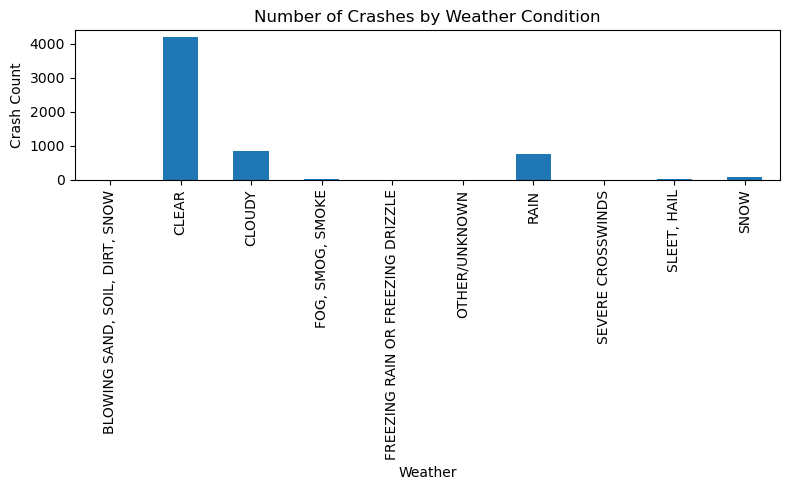

In [24]:
import matplotlib.pyplot as plt

merged = crash_df.merge(weather_df, on="Weather_ID")

crashes_by_weather = merged.groupby("Weather").size()

plt.figure(figsize=(8,5))
crashes_by_weather.plot(kind="bar")
plt.title("Number of Crashes by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Crash Count")
plt.tight_layout()
plt.show()


- **Clear Skies, Higher Risk** : The highest number of crashes occured in "Clear" weather conditions, contrary 
to  
common assumptions. This could be due to people being less mindful of their driving as the weather is optimal  
and there are not many reasons to be cautious.    
- **Cloudy with a Chance of Crashes** : Cloudy and rainy conditions are associated with the next highest  
number of crashes.  
- **Snow days - Safe Roads** : Snowy days and days with sleet and hail conditions recorded an extremely  
low number crashes, suggesting that most drivers are either bundled up at home or become highly cautious!
- Overall, the data shows that ***bad weather conditions are not highly correlated with crashes*** and that on the contrary,  
people must excercise more caution on the "Clear" days.


##### B) Which Road Type is associated with the Highest Number of Crashes?

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Road_Type'>

Text(0.5, 1.0, 'Crashes by Road Type')

Text(0.5, 0, 'Road Type')

Text(0, 0.5, 'Crash Count')

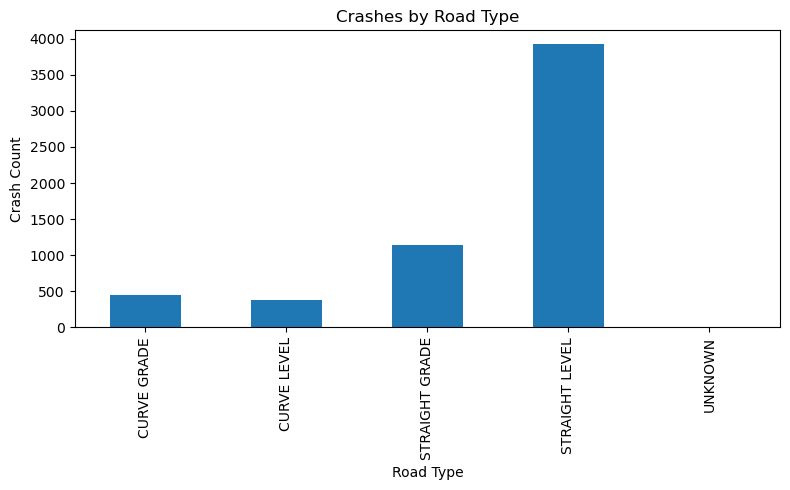

In [25]:
merged = crash_df.merge(road_df, on="Road_ID")

crashes_by_road = merged.groupby("Road_Type").size()

plt.figure(figsize=(8,5))
crashes_by_road.plot(kind="bar")
plt.title("Crashes by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Crash Count")
plt.tight_layout()
plt.show()


- **Straight does not mean Safe** : Straight roads account for the highest number of crashes, suggesting that high-speed or more frequent travel on these roads may contribute to greater risk. Driver fatigue can also be a possible reason for causing more frequent crashes. 
- **More Curves = More Caution** : Curve-level and Curve-grade roads have relatively fewer crashes, which may imply that drivers exercise more caution on curves.  
- Overall, ***road type plays a significant role in crash frequency***, with straight, level roads being the most dangerous

#### C) Who is at the Highest Risk of Injury during the crashes?

<Figure size 600x400 with 0 Axes>

C:\Users\Nida Aslam\AppData\Local\Temp\ipykernel_18476\199959891.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Role'>

Text(0.5, 1.0, 'Number of People Involved in Crashes by Role')

Text(0, 0.5, 'Count')

Text(0.5, 0, 'Role')

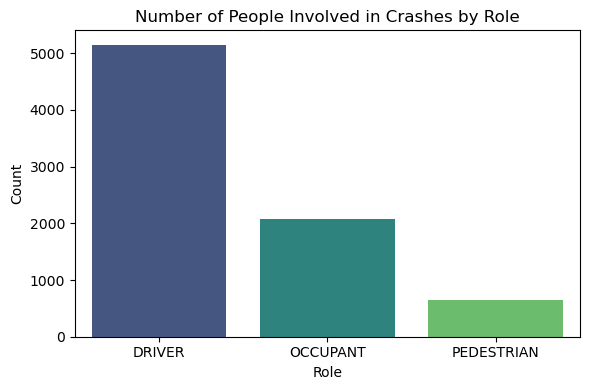

In [26]:
import seaborn as sns
import plotly.express as px

# Rename 'Injured' column to Role for clarity
person_df = person_df.rename(columns={'Injured': 'Role'})

# Merge tables
merged = crash_df.merge(vehicle_df, on="Crash_ID").merge(person_df, on="Vehicle_ID")

role_counts = merged['Role'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=role_counts.index, y=role_counts.values, palette="viridis")
plt.title("Number of People Involved in Crashes by Role")
plt.ylabel("Count")
plt.xlabel("Role")
plt.tight_layout()
plt.show()


- **Drivers, beware** : Drivers are involved in the vast majority of crashes, indicating that drivers are at the highest risk and that driver behavior might be a leading cause of crashes.
- **Passengers, be cautious** : Passeengers make up a smaller but significant portion of those involved, highlighting the importance of passenger safety measures.  
- **Look to your Left, look to your Right** : Pedestrians account for the fewest incidents, suggesting that while pedestrian crashes are less frequent, they remain a critical safety concern.  
- Overall, the data emphasizes that ***crash prevention efforts should focus primarily on drivers***, while also considering occupant and pedestrian safety.

#### E) How do Weather Conditions and Road Type affect Crashes?

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='Road_Type', ylabel='Weather'>

Text(0.5, 1.0, 'Number of Crashes by Weather and Road Type')

Text(70.7222222222222, 0.5, 'Weather')

Text(0.5, 36.72222222222221, 'Road Type')

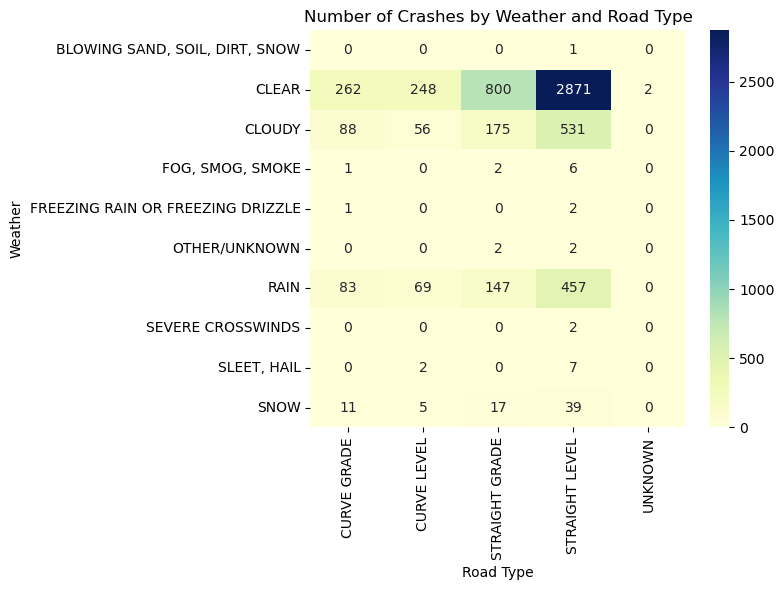

In [27]:
merged3 = crash_df.merge(weather_df, on="Weather_ID").merge(road_df, on="Road_ID")
heat_data = pd.crosstab(merged3['Weather'], merged3['Road_Type'])

plt.figure(figsize=(8,6))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Crashes by Weather and Road Type")
plt.ylabel("Weather")
plt.xlabel("Road Type")
plt.tight_layout()
plt.show()


- **The Most Optimal conditions = The Highest Number of Crashes** : Surprisingly, the data shows the highest number of  
crashes (2,871) taking place in Clear weather conditions and on Straight-level roads. This could be due to driver fatigue, less  
cautious behavior or more frequent travel in such conditions. 
- **Cloudy and Rainy conditions are risky** : Cloudy and rainy conditions on straight leveel roads contribute to a  
high number of crashes, suggesting that drivers must excercise more caution during such conditions.
- Overall, the data suggests that more crashes occur during more optimal conditions, indicating that there needs  
to be ***more emphasis on driver safety measures*** such as how to battle driver faitgue, boredom, eetc. 

#### F) Are there certain days or times associated with a higher number of crashes?

In [28]:
crash_df['Hour'] = crash_df['Date'].dt.hour
crash_df['DayOfWeek'] = crash_df['Date'].dt.day_name()

heat_data = pd.crosstab(crash_df['Hour'], crash_df['DayOfWeek'])

fig_hour_day = px.imshow(
    heat_data.values,
    x=heat_data.columns, y=heat_data.index,
    labels=dict(x="Day of Week", y="Hour of Day", color="Crash Count"),
    title="Crashes by Hour and Day of Week",
    text_auto=True
)
fig_hour_day.show()


- **Friday Rush Hour** : The data shows that the highest number of crashes occur on Fridays at 4pm, along with most crashs happening between 3pm to 5pm. This could be due to more people driving back from work and speeding to get home in anticipating of a relaxing weekend.
- **The Early Birds are the Safest** : There are a significantly lower number of crashes in from midnight until 5am. This could be due to a fewer number of night drivers who excercise a higher amount of caution. However, it is interesting  
to note that the frequency of crashes increase as we get closer to 8am, i.e., the morning rush hour. 
- Overall, the data shows that there are a ***higher number of crashes associated with the evening rush hours***, indicating that drivers must excercise more caution during these times. 

###                                       Interactive Dash Board
#### Input your desired date range, weather conditions, road type or role to slice the data as you wish.

In [29]:
# ===============================
# 1️⃣ Imports
# ===============================
import plotly.express as px
import pandas as pd



In [30]:
# ===========================================
# Create merged DataFrames used in plots
# ===========================================

# Merge crash → vehicle → person → weather
merged = (crash_df
          .merge(vehicle_df, on='Crash_ID', how='left')
          .merge(person_df, on='Vehicle_ID', how='left')
          .merge(weather_df, on='Weather_ID', how='left')
         )

# Merge crash → road → weather
merged_crash_road = (crash_df
                     .merge(road_df, on='Road_ID', how='left')
                     .merge(weather_df, on='Weather_ID', how='left')
                    )


In [31]:
# ===============================
# 1️⃣ Imports
# ===============================
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# ===============================
# 2️⃣ Preprocessing / Reuse merged DataFrames
# ===============================
# merged: Crash → Vehicle → Person → Weather
# merged_crash_road: Crash → Road → Weather
person_df = person_df.rename(columns={'Injured': 'Role'})
injured_people = merged[merged['Injury'].notna()]

# Convert Date to datetime if not already
crash_df['Date'] = pd.to_datetime(crash_df['Date'])

# ===============================
# 3️⃣ Initialize Dash App
# ===============================
app = dash.Dash(__name__)
app.title = "Enhanced Crash Dashboard"

# ===============================
# 4️⃣ Layout
# ===============================
app.layout = html.Div(
    style={
        "backgroundColor": "white",   # White background
        "color": "black",             # Black text
        "minHeight": "100vh",
        "padding": "20px"
    },
    children=[
        html.H1("Enhanced Crash Data Dashboard", style={'textAlign': 'center'}),

        # --- Filters ---
        html.Div([
            html.Label("Select Date Range:"),
            dcc.DatePickerRange(
                id='date-range',
                min_date_allowed=crash_df['Date'].min(),
                max_date_allowed=crash_df['Date'].max(),
                start_date=crash_df['Date'].min(),
                end_date=crash_df['Date'].max()
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Label("Select Weather:"),
            dcc.Dropdown(
                id='weather-filter',
                options=[{'label': w, 'value': w} for w in merged['Weather'].unique()],
                value=None,
                multi=True,
                placeholder="All Weather Types"
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Label("Select Road Type:"),
            dcc.Dropdown(
                id='road-filter',
                options=[{'label': r, 'value': r} for r in merged_crash_road['Road_Type'].unique()],
                value=None,
                multi=True,
                placeholder="All Road Types"
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Label("Select Role:"),
            dcc.Dropdown(
                id='role-filter',
                options=[{'label': r, 'value': r} for r in merged['Role'].unique()],
                value=None,
                multi=True,
                placeholder="All Roles"
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'}),

        html.Hr(),

        # --- Summary Metrics ---
        html.Div(id='summary-metrics', style={'display':'flex', 'justify-content':'space-around', 'padding':'10px'}),

        html.Hr(),

        # --- Charts ---
        html.Div([
            dcc.Graph(id='chart-role'),
            dcc.Graph(id='chart-road'),
            dcc.Graph(id='chart-weather'),
            dcc.Graph(id='chart-heatmap'),
            dcc.Graph(id='chart-age')
        ])
    ]
)

# ===============================
# 5️⃣ Callback to update charts and summary
# ===============================
@app.callback(
    [Output('summary-metrics', 'children'),
     Output('chart-role', 'figure'),
     Output('chart-road', 'figure'),
     Output('chart-weather', 'figure'),
     Output('chart-heatmap', 'figure'),
     Output('chart-age', 'figure')],
    [Input('date-range', 'start_date'),
     Input('date-range', 'end_date'),
     Input('weather-filter', 'value'),
     Input('road-filter', 'value'),
     Input('role-filter', 'value')]
)
def update_dashboard(start_date, end_date, selected_weather, selected_road, selected_role):

    # Filter by date
    df_filtered = merged[(merged['Date'] >= pd.to_datetime(start_date)) & (merged['Date'] <= pd.to_datetime(end_date))]
    df_filtered_road = merged_crash_road[(merged_crash_road['Date'] >= pd.to_datetime(start_date)) &
                                         (merged_crash_road['Date'] <= pd.to_datetime(end_date))]

    # Apply additional filters
    if selected_weather:
        df_filtered = df_filtered[df_filtered['Weather'].isin(selected_weather)]
        df_filtered_road = df_filtered_road[df_filtered_road['Weather'].isin(selected_weather)]
    if selected_road:
        df_filtered_road = df_filtered_road[df_filtered_road['Road_Type'].isin(selected_road)]
    if selected_role:
        df_filtered = df_filtered[df_filtered['Role'].isin(selected_role)]

    # --- Summary Metrics ---
    total_crashes = df_filtered['Crash_ID'].nunique()
    total_people = df_filtered['PersonID'].nunique()
    total_injuries = df_filtered[df_filtered['Injury'].notna()]['PersonID'].nunique()
    most_common_weather = df_filtered['Weather'].mode()[0] if not df_filtered.empty else "N/A"

    summary = [
        html.Div([html.H3("Total Crashes"), html.P(f"{total_crashes}")],
                 style={'padding':'10px', 'border':'1px solid black', 'border-radius':'5px'}),
        html.Div([html.H3("Total People Involved"), html.P(f"{total_people}")],
                 style={'padding':'10px', 'border':'1px solid black', 'border-radius':'5px'}),
        html.Div([html.H3("Total Injured People"), html.P(f"{total_injuries}")],
                 style={'padding':'10px', 'border':'1px solid black', 'border-radius':'5px'}),
        html.Div([html.H3("Most Common Weather"), html.P(f"{most_common_weather}")],
                 style={'padding':'10px', 'border':'1px solid black', 'border-radius':'5px'}),
    ]

    # --- Charts ---
    # People by Role
    role_counts = df_filtered['Role'].value_counts().reset_index()
    role_counts.columns = ['Role', 'Count']
    fig_role = px.bar(role_counts, x='Role', y='Count', text='Count', color='Role',
                      title="Number of People Involved by Role")

    # Crashes by Road Type
    crashes_by_road = df_filtered_road['Road_Type'].value_counts().reset_index()
    crashes_by_road.columns = ['Road_Type', 'Crash_Count']
    fig_road = px.bar(crashes_by_road, x='Road_Type', y='Crash_Count', text='Crash_Count',
                      color='Road_Type', title="Number of Crashes by Road Type")

    # Crashes by Weather
    crashes_by_weather = df_filtered_road['Weather'].value_counts().reset_index()
    crashes_by_weather.columns = ['Weather', 'Crash_Count']
    fig_weather = px.bar(crashes_by_weather, x='Weather', y='Crash_Count', text='Crash_Count',
                         color='Weather', title="Number of Crashes by Weather")

    # Heatmap: Crashes by Weather and Road Type
    heat_data = pd.crosstab(df_filtered_road['Weather'], df_filtered_road['Road_Type']).reset_index()
    fig_heatmap = px.imshow(heat_data.set_index('Weather').values,
                            x=heat_data.columns[1:], y=heat_data['Weather'],
                            labels=dict(x="Road Type", y="Weather", color="Crash Count"),
                            text_auto=True,
                            title="Crashes by Weather and Road Type")

    # Age Distribution
    age_bins = [0, 18, 25, 35, 45, 55, 65, 75, 100]
    fig_age = px.histogram(df_filtered, x='Age', nbins=len(age_bins)-1,
                           title="Age Distribution of People Involved in Crashes",
                           category_orders={'Age': sorted(df_filtered['Age'].dropna().unique())})

    return summary, fig_role, fig_road, fig_weather, fig_heatmap, fig_age

# ===============================
# 6️⃣ Run the app
# ===============================
if __name__ == '__main__':
    app.run(debug=True)
